## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn

from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

### Utility Functions

In [274]:
def do_binary_classification(model, X, labels, optimizer = torch.optim.RMSprop, loss_function = nn.BCEWithLogitsLoss(), epochs = 81):

    optimizer = optimizer(model.parameters(), lr = 0.1)

    # optimize model through iterative guessing and parameter updates
    for epoch in range(epochs):
        # reset gradients
        optimizer.zero_grad()

        # predict output with model
        y_pred = model(X)

        # calculate prediction loss
        loss = loss_function(y_pred.squeeze(), labels.float())

        # do backpropagation to get gradients
        loss.backward()

        # update model parameters
        optimizer.step()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, Loss: {loss.item():.4f}")
            probs = torch.sigmoid(y_pred)
            plt.figure()
            plt.title(f"\nepoch={epoch}, loss={loss:.4f}")
            plt.scatter(*X.T, s = 20, c = probs > 0.5, cmap='Set1');


def do_multiclass_classification(X, labels, optimizer = torch.optim.Adam, loss_function = nn.CrossEntropyLoss(), epochs = 11):

    torch.manual_seed(2025)
    model = nn.Sequential(
        nn.Linear(4,16),
        nn.ReLU(),
        nn.Linear(16,3),
    )

    optimizer = optimizer(model.parameters(), lr = 0.1)

    # optimize model through iterative guessing and parameter updates
    for epoch in range(epochs):
        # reset gradients
        optimizer.zero_grad()

        # predict output with model
        y_pred = model(X)

        # calculate prediction loss
        loss = loss_function(y_pred.squeeze(), labels)

        # do backpropagation to get gradients
        loss.backward()

        # update model parameters
        optimizer.step()

        if epoch % 2 == 0:
            print(f"epoch {epoch}, Loss: {loss.item():.4f}")
            probs = torch.softmax(y_pred, dim=1).detach().numpy()
            plt.figure()
            plt.title(f"\nepoch={epoch}, loss={loss:.4f}")
            plt.scatter(X[:,0], X[:,1], s = 20, c = np.argmax(probs, axis=1))#, cmap='tab10');
            plt.xlabel('Feature 1')
            plt.ylabel('Feature 2')
    return probs


class utils:
    do_binary_classification = do_binary_classification
    do_multiclass_classification = do_multiclass_classification

### Generate Data

#### For Binary Classification

In [173]:
X_orig, labels_orig = make_moons(256, noise=0.1, random_state=42)

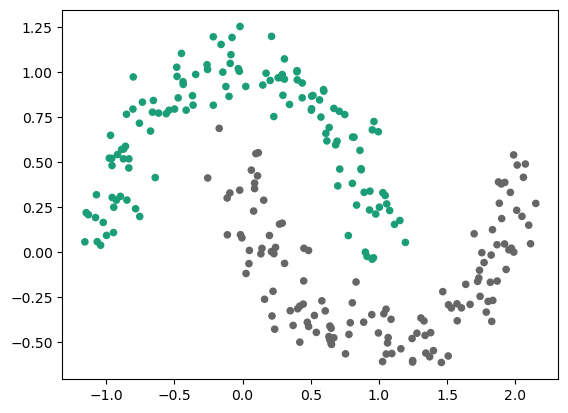

In [174]:
# This makes an independent copy (recommended in most cases)
X = torch.tensor(X_orig, dtype=torch.float32)
labels = torch.tensor(labels_orig, dtype=torch.long)


plt.scatter(*X.T, s = 20, c = y, cmap='Dark2');

## Section 1: Capturing Non-Linear Decision Boundaries

Often, the relationship you want to uncover in your data isn't linear. In this section, we'll see how to make neural network models that can capture non-linear patterns in the data.

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `nn.ReLU()` | Creates a rectified linear unit (ReLU) activation function.|
| `nn.Tanh()` | Creates hyperbolic tangent activation function.|
| `nn.Sigmoid()` | Creates a sigmoid activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|
| `utils.do_binary_classification(model, X, labels)` | Do binary classification. `X` is the input data and `labels` are the true class labels for the data. |
| `utils.do_binary_classification(model, X, labels, epochs=200)` | Do binary classification and set the number of epochs to 200. |

**Exercise**: Create a linear model (like the one we used in the previous session) with 2 input features and 1 output feature. Pass this model as input to the function `utils.do_binary_classification`. Is this model able to do the classification correctly?

epoch 0, Loss: 0.7810
epoch 20, Loss: 0.2782
epoch 40, Loss: 0.2699
epoch 60, Loss: 0.2681
epoch 80, Loss: 0.2676


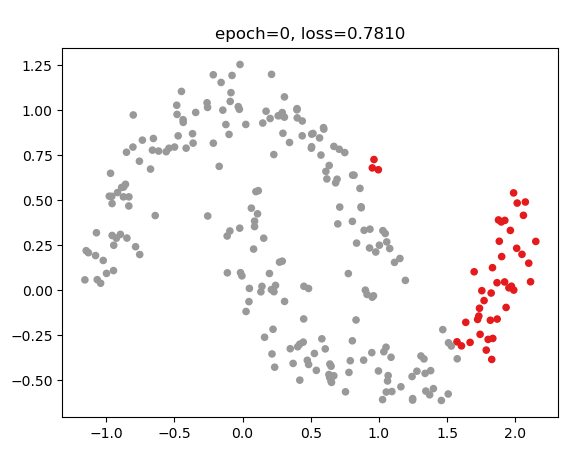

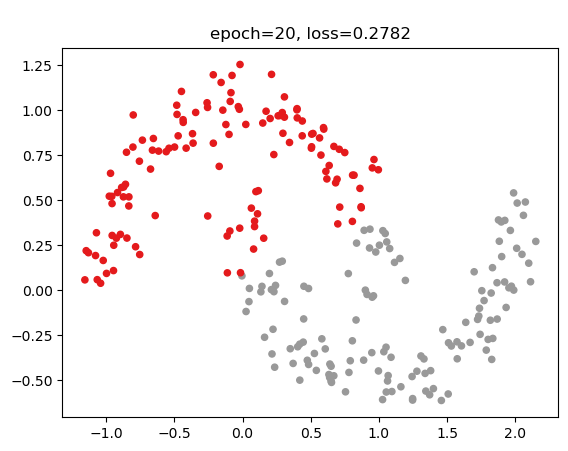

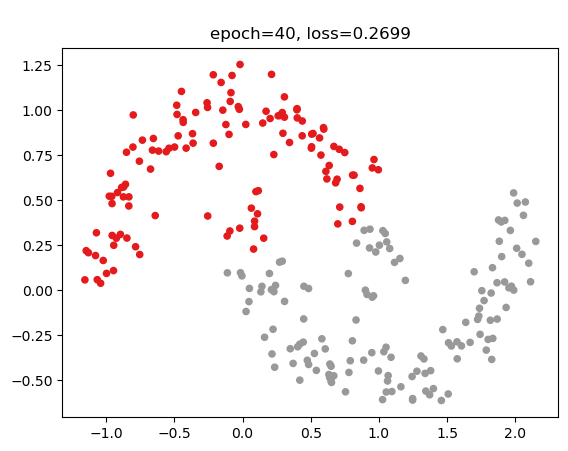

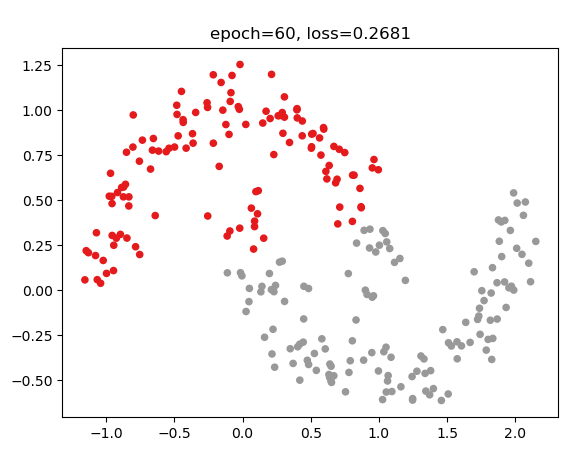

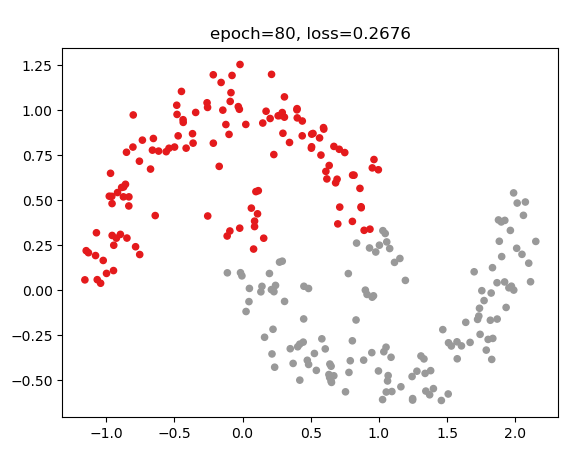

In [175]:
# create model
model = nn.Linear(2,1)

utils.do_binary_classification(model, X, labels)

**Exercise**: Use the same model to do binary classification but this time, try increasing the number of epochs (no need to go beyond 200). Is the model able to do the classification correctly now?

epoch 0, Loss: 0.5437
epoch 20, Loss: 0.2749
epoch 40, Loss: 0.2687
epoch 60, Loss: 0.2677
epoch 80, Loss: 0.2675
epoch 100, Loss: 0.2675
epoch 120, Loss: 0.2674
epoch 140, Loss: 0.2684
epoch 160, Loss: 0.2674
epoch 180, Loss: 0.2674


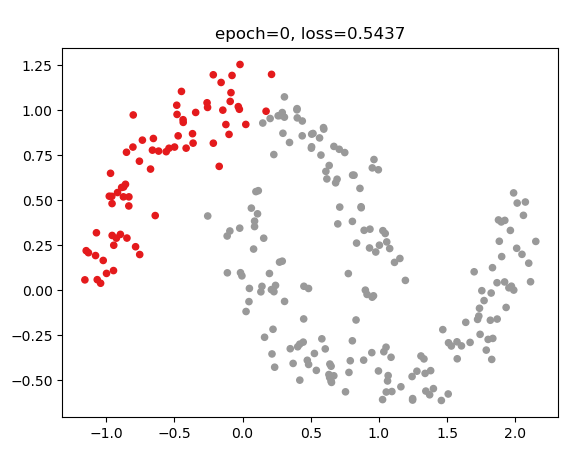

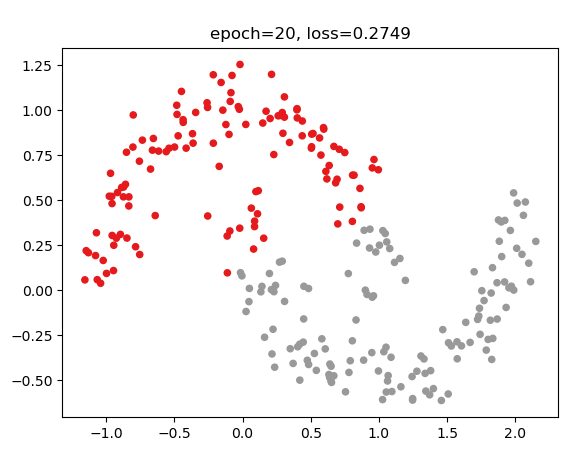

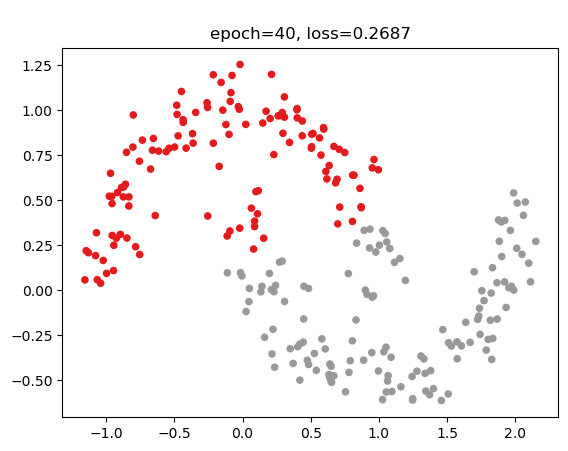

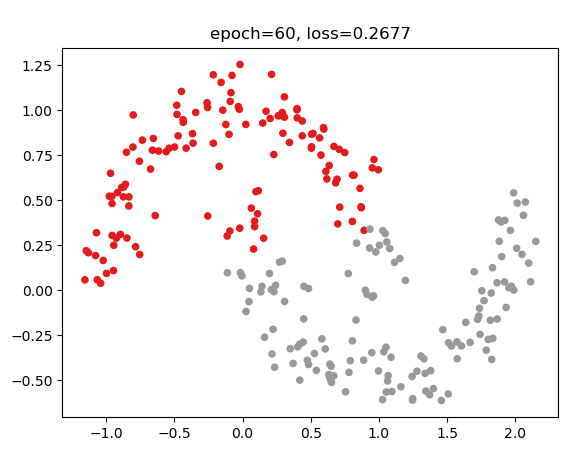

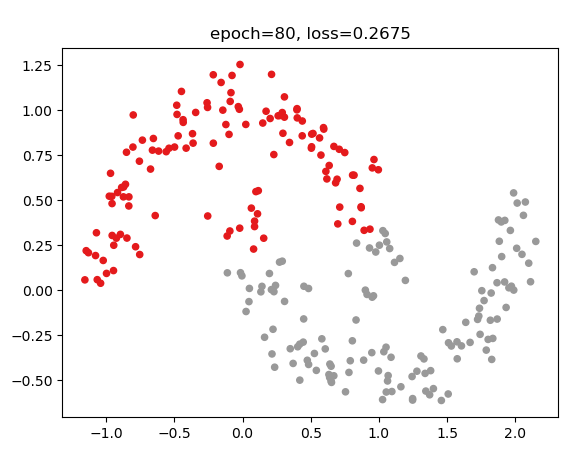

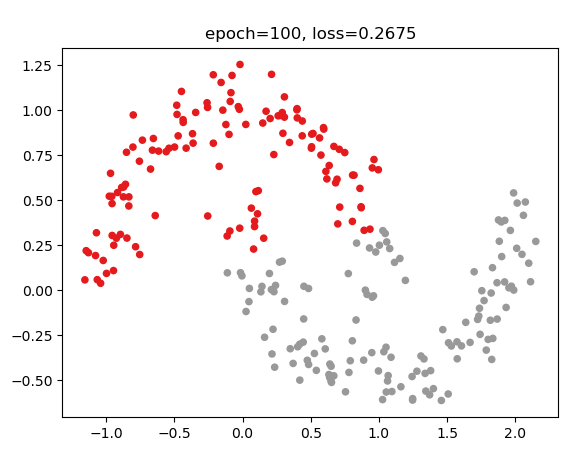

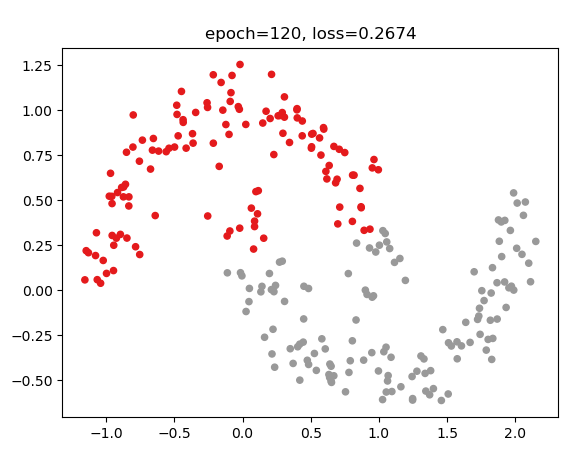

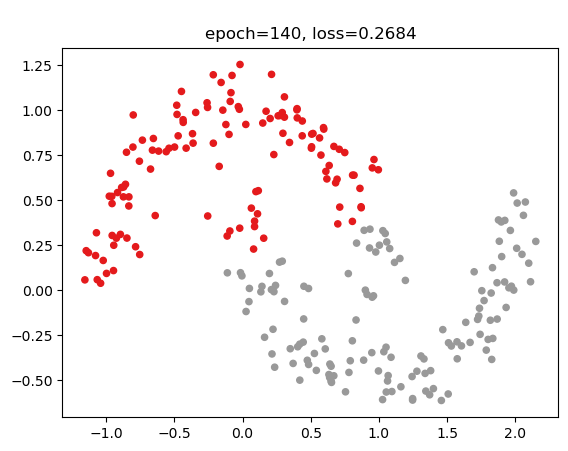

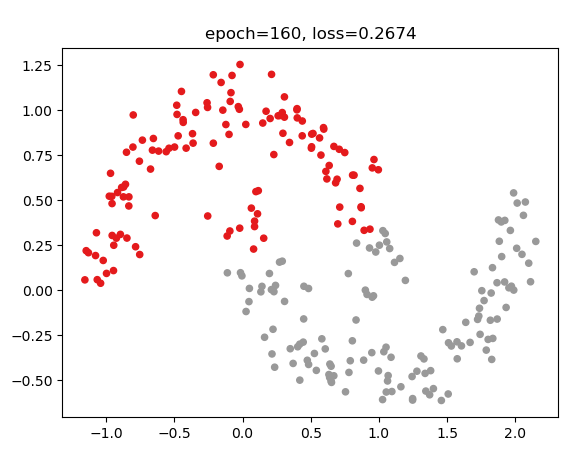

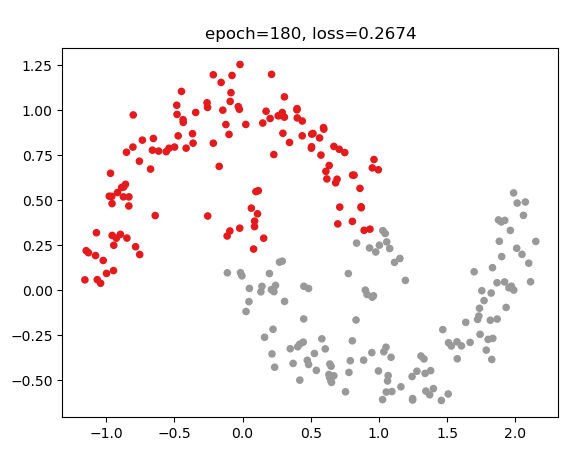

In [ ]:
# create model
model = nn.Linear(2,1)

utils.do_binary_classification(model, X, labels, epochs=200)

Even if the result might have improved a little bit, the linear model isn't able to do the classification correctly for all points, no matter how many epochs we train the model for. The reason is that this is a *non-linaer* problem, and a linear model will not be able to capture the non-linearities in the data. The way this has been solved for neural networks, is to add an *activation function* to the model.

**Example**: Create a model composed of two layers with a *rectified linear* unit between them. The first layer has two input features and one 16 output features, the last layer has 16 input features and 1 output feature. Pass the model to the utility function `utils.do_binary_classification`. Is the model able to correctly classify the points now?

epoch 0, Loss: 0.6965
epoch 20, Loss: 0.1226
epoch 40, Loss: 0.0418
epoch 60, Loss: 0.0218
epoch 80, Loss: 0.0140


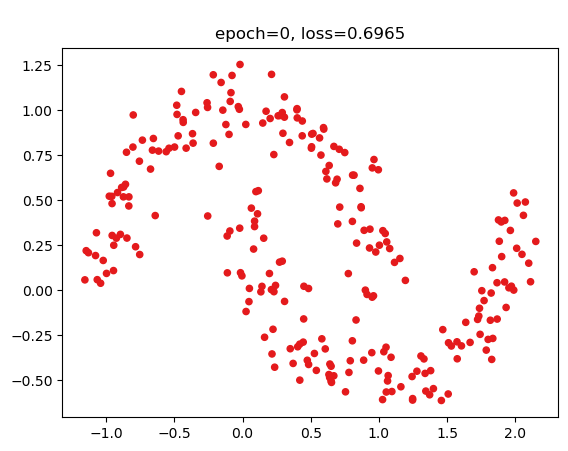

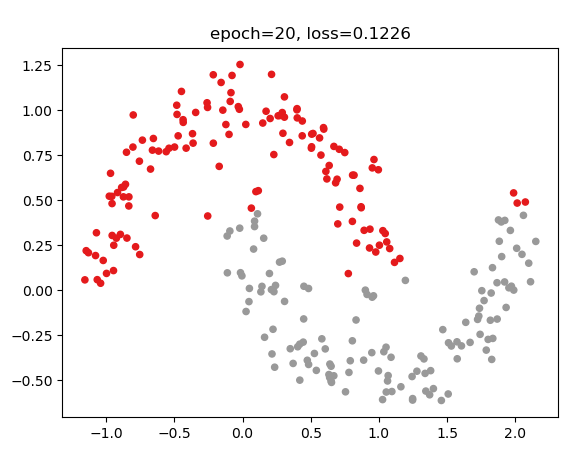

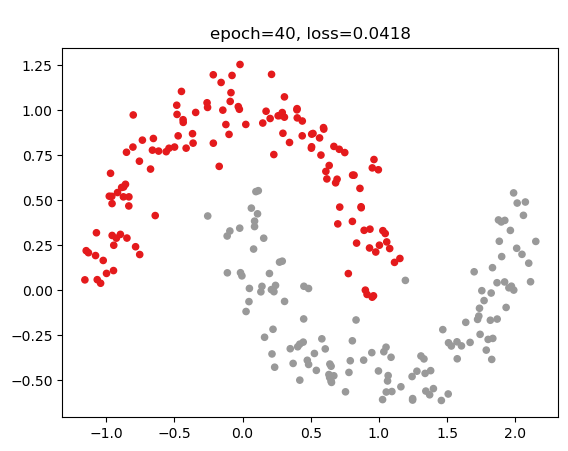

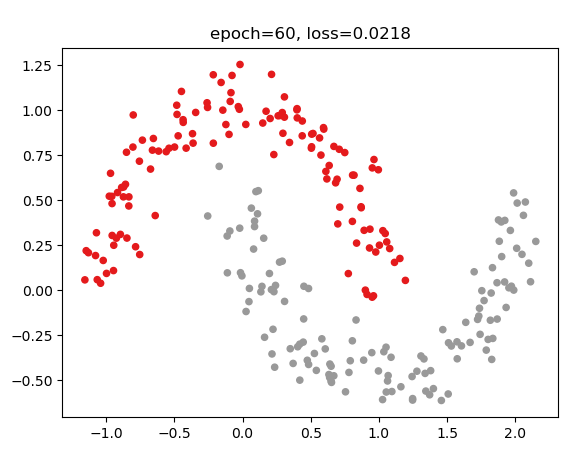

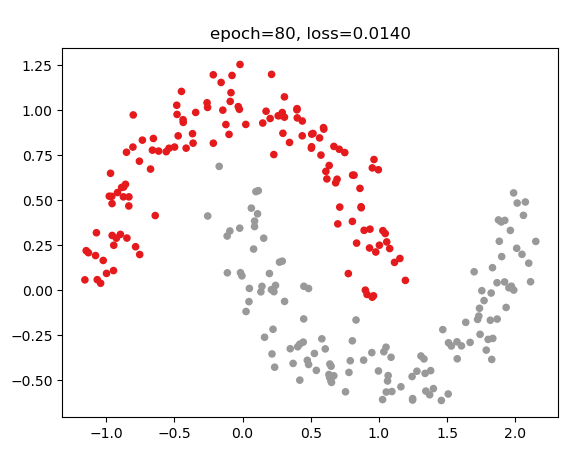

In [176]:
torch.manual_seed(2025)
# create model
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

utils.do_binary_classification(model, X, labels)

There are different kinds of activation functions. Let's take a look at what some of the most common ones actually do.

**Exercise**: Create a rectified linear unit (ReLU) activation function and assign it to a variable called `activation_function`.

In [8]:
activation_function = nn.ReLU()
activation_function

ReLU()

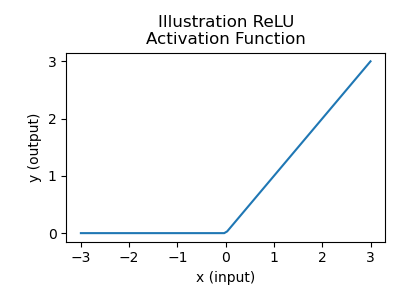

In [14]:
Image("img/illustration_relu.png")

**Exercise**: Pass the random input generated below to the ReLU activation function you just created and print the result. Compare the output to the random input. What happens to the negative and what happens to the positive numbers in the input?

In [103]:
torch.manual_seed(2025)
input = torch.randn(20)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [104]:
activation_function(input)

tensor([0.0000, 0.0000, 0.7782, 0.0000, 0.4670, 1.1802, 0.3709, 0.0000, 0.0000,
        0.0000, 0.0000, 2.7671, 0.0000, 0.3533, 0.0000, 0.0000, 0.9320, 0.0000,
        0.0000, 0.5447])

**Demo**: Run the cell below to see a plot of the original input and the output from the activation function together. This visualizes the effect of the ReLU.

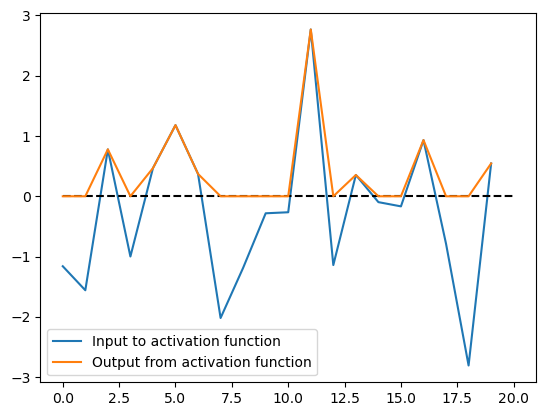

In [107]:
plt.plot(np.arange(len(input)), input, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(input), y=0, ls='--', colors='k')
plt.plot(np.arange(len(input)), activation_function(input), label ='Output from activation function')
plt.legend()

**Exercise**: Create a hyperbolic tangent activation function and assign it to a variable named `activation_function`.

In [177]:
activation_function = nn.Tanh()
activation_function

Tanh()

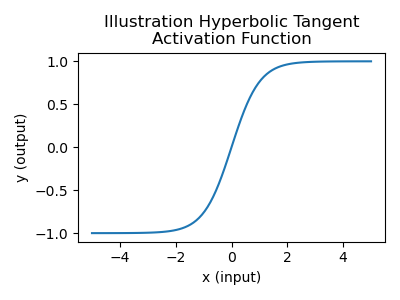

In [178]:
Image("img/illustration_tanh.png")

**Exercise**: Pass the random input generated below to the hyperbolic tangent activation function you just created and print the result. Compare the output to the random input. What happens to the negative and what happens to the positive numbers in the input? (You can also use the visualization in the demo below to assess this.)

In [179]:
torch.manual_seed(2025)
input = torch.randn(20)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [180]:
activation_function(input)

tensor([-0.8213, -0.9153,  0.6517, -0.7612,  0.4358,  0.8275,  0.3548, -0.9654,
        -0.8297, -0.2749, -0.2591,  0.9921, -0.8149,  0.3393, -0.0969, -0.1659,
         0.7315, -0.6574, -0.9927,  0.4965])

**Demo**: Run the cell below to see a plot of the original input and the output from the activation function together. This visualizes the effect of the hyperbolic tangent activation function.

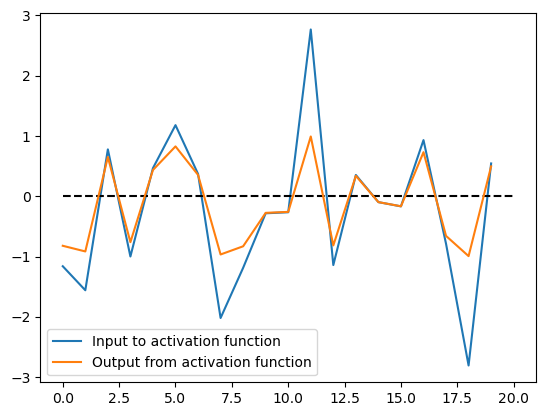

In [ ]:
plt.plot(np.arange(len(input)), input, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(input), y=0, ls='--', colors='k')
plt.plot(np.arange(len(input)), activation_function(input), label ='Output from activation function')
plt.legend();

**Exercise**: Create a sigmoid activation function and assign it to a variable named `activation_function`.

In [182]:
activation_function = nn.Sigmoid()
activation_function

Sigmoid()

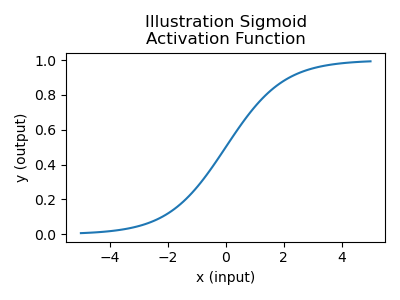

In [183]:
Image("img/illustration_sigmoid.png")

**Exercise**: Pass the random input generated below to the hyperbolic tangent activation function you just created and print the result. Compare the output to the random input. What happens to the negative and what happens to the positive numbers in the input?

In [184]:
activation_function(input)

tensor([0.2385, 0.1738, 0.6853, 0.2691, 0.6147, 0.7650, 0.5917, 0.1172, 0.2338,
        0.4299, 0.4341, 0.9409, 0.2421, 0.5874, 0.4757, 0.4582, 0.7175, 0.3126,
        0.0569, 0.6329])

**Demo**: Run the cell below to see a plot of the original input and the output from the activation function together. This visualizes the effect of the sigmoid activation function.

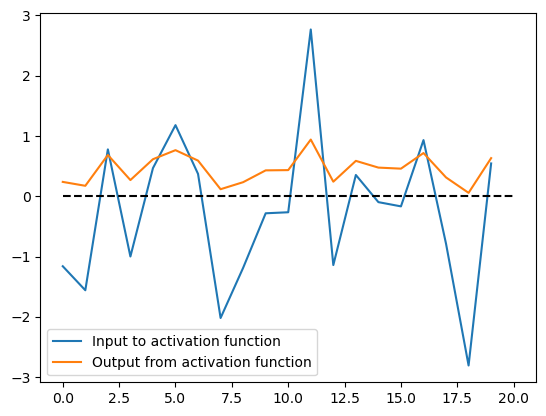

In [187]:
plt.plot(np.arange(len(input)), input, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(input), y=0, ls='--', colors='k')
plt.plot(np.arange(len(input)), activation_function(input), label ='Output from activation function')
plt.legend();

Historically, the hyperbolic tangent activation function was used because it most closely mimicked the action of the axon hillock on a neuron. However, it was later shown that the rectified linear unit often produced better results [reference], and since then, it's been the most commonly used activation function in neural networks. Sigmoid activation functions are often used to convert the output at the end of a network to probabilities between 0 and 1, which is particularly relevant for binary classification problems.

## Section 2: The Loss Function for Binary Classification Problems

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `nn.ReLU()` | Creates a rectified linear unit (ReLU) activation function.|
| `nn.Tanh()` | Creates hyperbolic tangent activation function.|
| `nn.Sigmoid()` | Creates a sigmoid activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|
| `utils.do_binary_classification(model, X, labels, loss_function=nn.MSELoss())` | Do binary classification and set the loss function to torch's mean square error. |
| `utils.do_binary_classification(model, loss_function=nn.BCEWithLogitsLoss())` | Do binary classification and set the loss function to torch's cross entropy loss for binary classification. |

You may have noticed the use of `nn.Sequential` to create the model in the first example in the previous section. It creates a container for the layers and activation functions of the neural network model and makes sure that when input is passed through the network, it's passed in the right (sequential) order.

**Exercise**: Create a sequence of layers with a rectified linear unit between them. The first layer should have two input features and 16 output features, the last layer should take in the 16 outputs from the first layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=16, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=16, out_features=2, bias=True)  <br>
)

**Hint**: See reference table for how to create an `nn.Sequential` container.

In [ ]:
nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)

**Exercise**: Create sequence of three linear layers with one hyperbolic tangent activation function and one rectified linear unit between the first and the second linear layer, respectively. The first layer should have two input features and 32 output features, the next linear layer should have 32 input features and 32 output features, the last layer should take in the 32 outputs from the previous layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): Tanh()  <br>
  &nbsp;&nbsp;(0): Linear(in_features=32, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=32, out_features=2, bias=True)  <br>
)

**Hint**: nn.Sequential (see reference table).

In [29]:
nn.Sequential(
    nn.Linear(2,32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.ReLU(),
    nn.Linear(16,2),
)

Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)

**Exercise**: Create a sequence of layers with a rectified linear unit between them and a sigmoid activation function at the end. Assign it to a variable named `model`.

The first layer should have two input features and 16 output features, the last layer should take in the 16 outputs from the first layer and output 1 feature.
When you display the `model`, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=16, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=16, out_features=2, bias=True)  <br>
  &nbsp;&nbsp;(3): Sigmoid() <br>
)



In [30]:
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1),
    nn.Sigmoid()
)
model

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): Sigmoid()
)

**Exercise**: Pass the model defined in the cell below to the `utils.do_binary_classification`. This is the same model as the one used in the example in the first section. This time, pass torch's mean squared error function `nn.MSELoss()` as the loss function to `utils.do_binary_classification`. How does the model perform now?

In [ ]:
torch.manual_seed(2025)
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1),
)

epoch 0, Loss: 69.5118
epoch 20, Loss: 3.0532
epoch 40, Loss: 1.6431
epoch 60, Loss: 1.1002
epoch 80, Loss: 0.7656


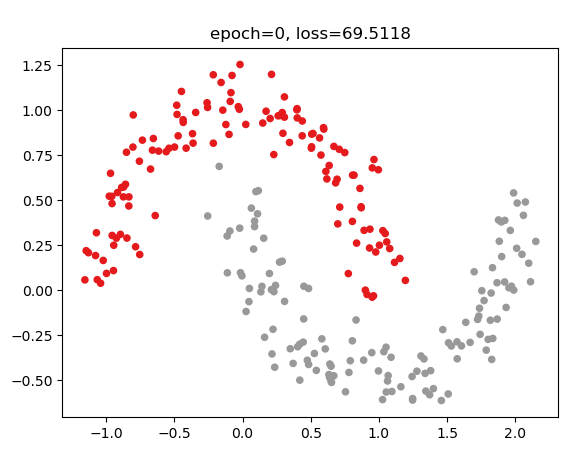

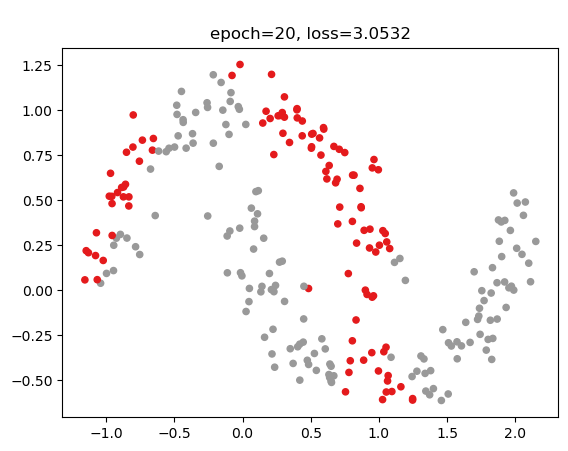

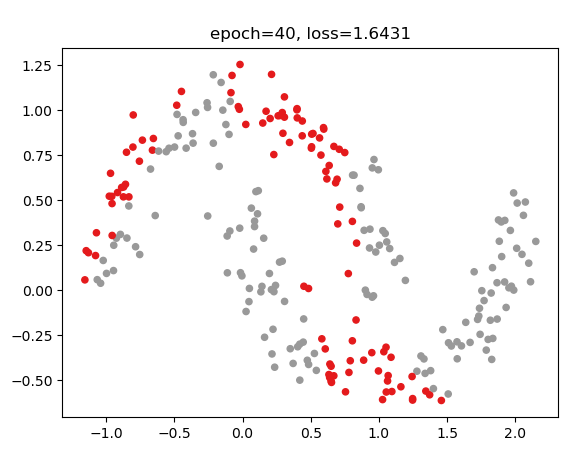

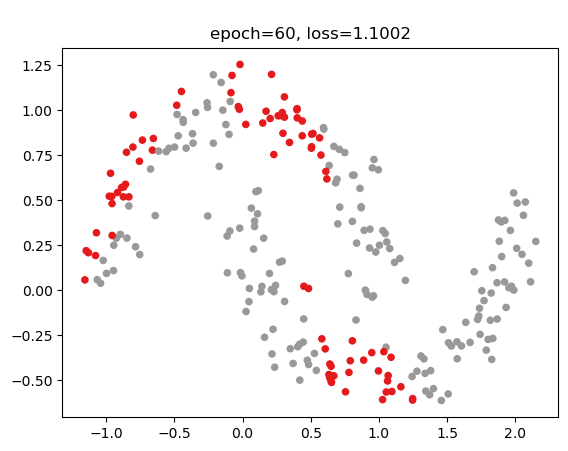

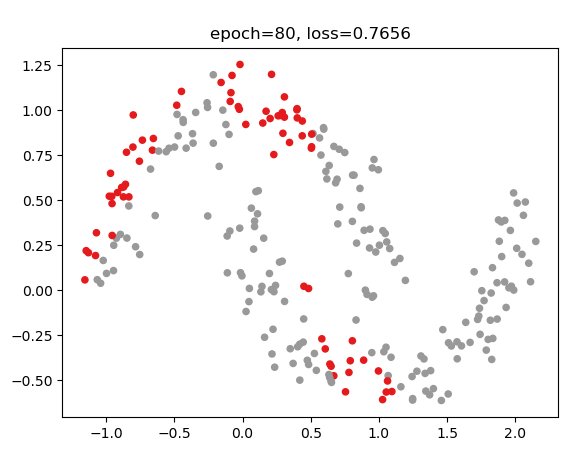

In [188]:
utils.do_binary_classification(model, X, labels, loss_function=nn.MSELoss())

It's not only the model that has to be appropriate for a classification problem, the loss function has to be appropriate too. The mean squared error, which worked well for regression in the previous session, is not suited for classification problems. The reason is that it's too lenient with confident but mistaken classifications - it doesn't penalize them harshly. For classification problems, something called cross entropy loss should be used instead.

**Exercise**: Use the same model, but pass the torch's bivariate cross-entropy loss function to `utils.do_binary_classification` instead of `nn.MSELoss()`. How is the convergence now?

Run the cell below that defines the model first, so we start with new weights and not the weights that were trained in the previous exercise.

In [36]:
torch.manual_seed(2025)
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1),
)

epoch 0, Loss: 0.6965
epoch 20, Loss: 0.1226
epoch 40, Loss: 0.0418
epoch 60, Loss: 0.0218
epoch 80, Loss: 0.0140


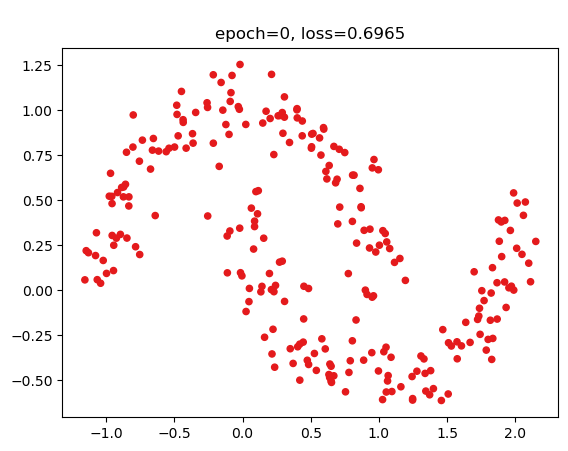

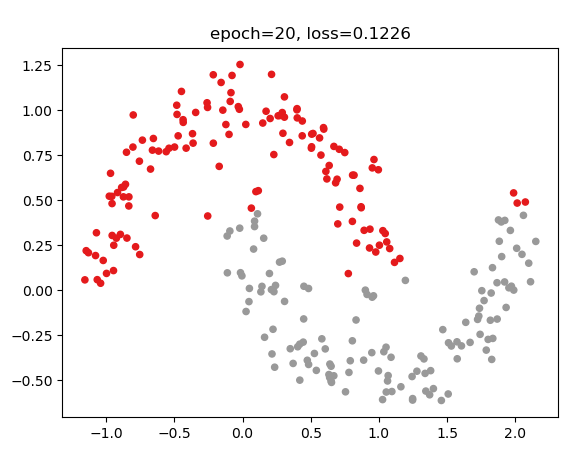

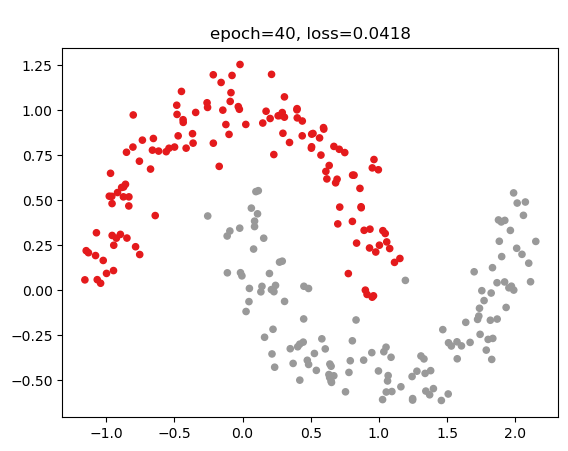

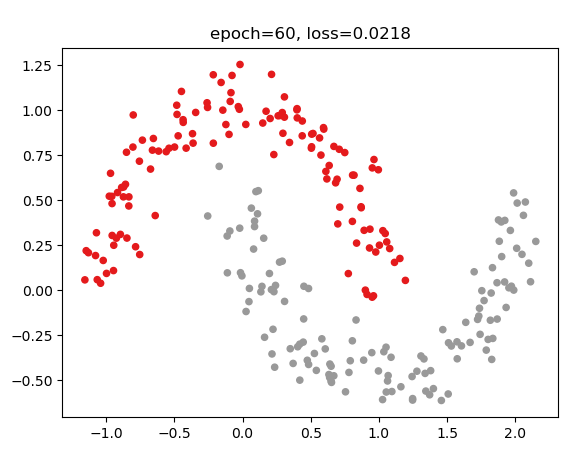

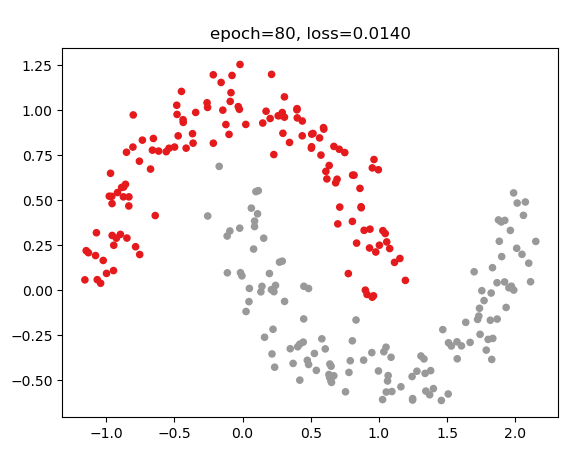

In [37]:
utils.do_binary_classification(model, loss_function=nn.BCEWithLogitsLoss())

## Section 3 Multiclass Classification and Optimizers


| Code | Description |
| --- | --- |
| `nn.CrossEntropyLoss()` | Creates a cross-entropy loss function. Used for classification problems.|
| `torch.optim.SGD(model.parameters())` | Creates a gradient descent (GD) optimizer. |
| `torch.optim.SGD(model.parameters(), lr=0.01, momentum = 0.99)` | Creates a gradient descent (GD) optimizer with a learning rate `lr` of 0.01 (the default value is 0.001) and ``momentum`` of 0.99 (the default value is 0.9). |
| `torch.optim.RMSprop(model.parameters())` | Creates an adaptive gradient descent optimizer.|
| `torch.optim.Adam(model.parameters())` | Creates an adaptive moment optimizer .|
| `utils.do_binary_classification(X, labels)` | Do multiclass classification. `X` is the input data and `labels` are the true class labels for the data. |
| `utils.do_binary_classification(X, labels, loss_function=nn.CrossEntropyLoss())` | Do multiclass classification and set the loss function to torch's cross entropy loss. |
| `utils.do_binary_classification(X, labels, optimizer=torch.optim.SGD)` | Do multiclass classification with gradient descent as the optimization algorithm. |

#### Generate Data for Multiclass Classification

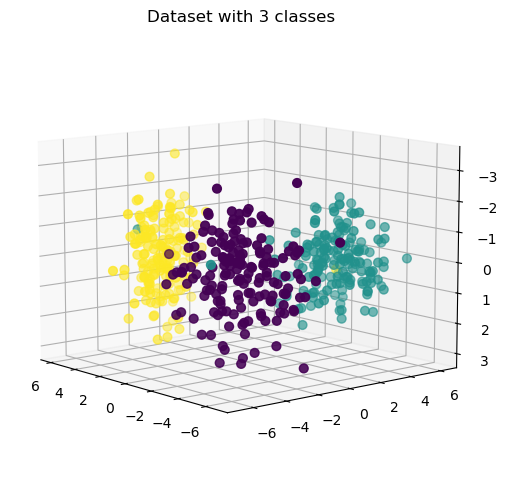

In [198]:
from sklearn import datasets

data = datasets.make_classification(n_classes=3, 
                                    n_features=4, 
                                    n_informative=3, 
                                    n_redundant=0, 
                                    n_samples=500, 
                                    n_clusters_per_class=1, 
                                    class_sep=3,
                                    random_state=2025)
# iris = datasets.load_iris()
# X = iris['data']
# labels = iris['target']
# labels

X = torch.tensor(data[0], dtype=torch.float32)
labels = torch.tensor(data[1], dtype=torch.int64)

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-170, azim=40)

ax.scatter(X[:,0], X[:,1], X[:,2], c = labels, s = 40);

ax.set_title("Dataset with 3 classes");

**Example**: Perform a multiclass classification on the data generated above.

**Hint**: Use the `utils.do_multiclass_classification` utility function.

epoch 0, Loss: 0.8184
epoch 2, Loss: 0.1222
epoch 4, Loss: 0.0965
epoch 6, Loss: 0.1142
epoch 8, Loss: 0.1157
epoch 10, Loss: 0.1027


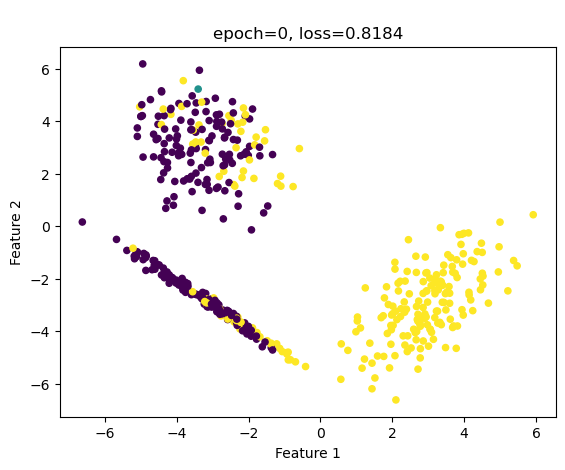

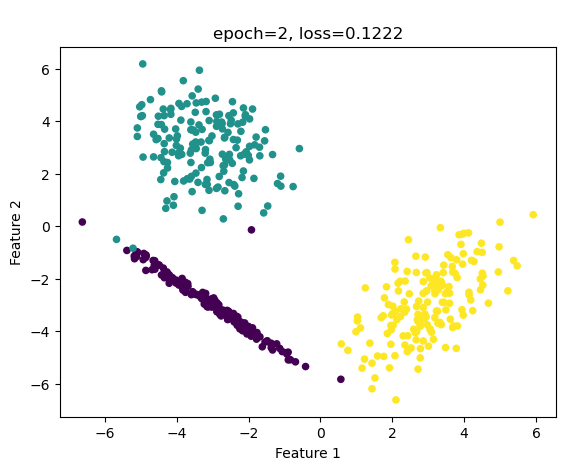

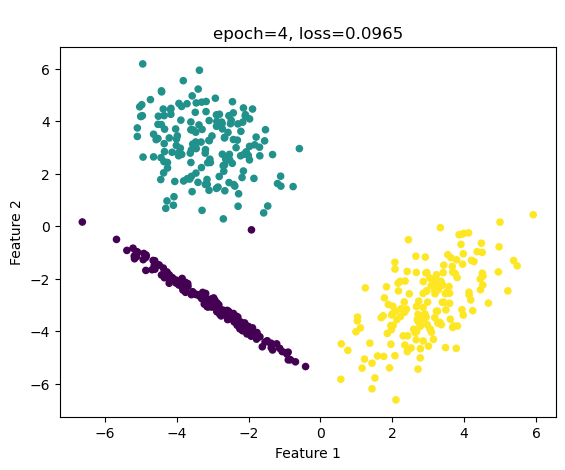

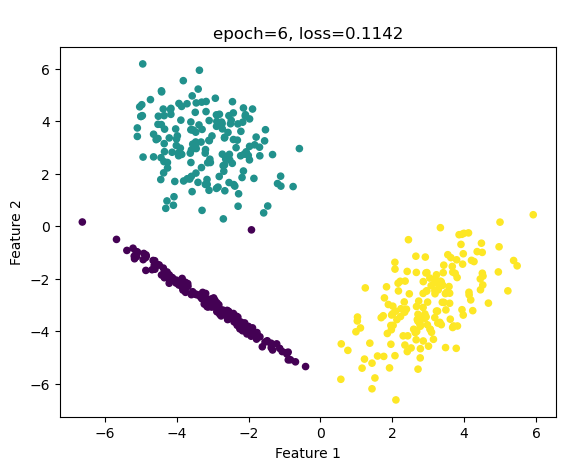

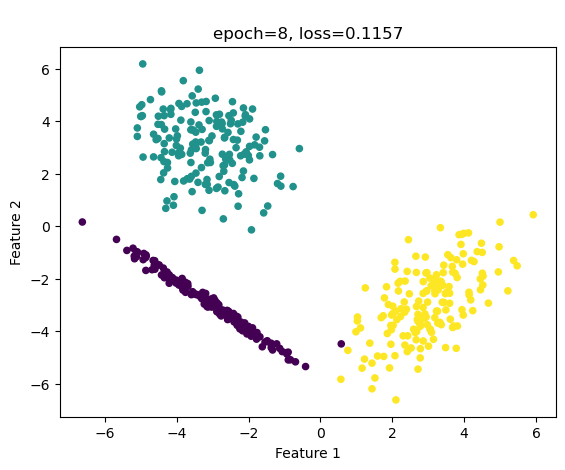

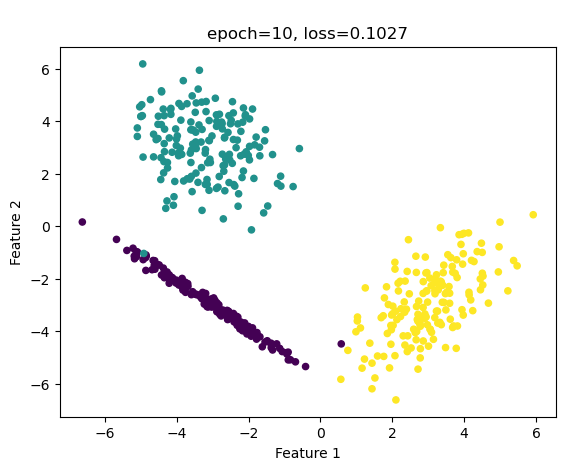

In [275]:
probs = utils.do_multiclass_classification(X=X, labels=labels,)

**Exercise**: Perform a multiclass classification on the same data, but this time, pass torch's `nn.BCEWithLogitsLoss()` loss function (the one we used for binary classification above) as the `loss_function` argument. What kind of error do you get? Can you guess why it doesn't work now even though it worked for the binary classification?

In [276]:
probs = utils.do_multiclass_classification(X=X, labels=labels,loss_function=nn.BCEWithLogitsLoss())

ValueError: Target size (torch.Size([500])) must be the same as input size (torch.Size([500, 3]))

As you might have guessed, the `nn.BCEWithLogitsLoss()` is made for binary classification problems. This is multiclass (more than 2) classification problem, so we have to use a different loss function. The typical torch function for multiclass classification is `nn.CrossEntropyLoss()`.[<sup>1</sup>](#fn1)

<span id="fn1"><sup>1</sup>You can actually use `nn.CrossEntropyLoss()` for binary classification problems as well, but it's less efficient.

**Exercise**: Perform a multiclass classification on the same data, but pass `nn.CrossEntropyLoss()` as the `loss_function` argument instead of `nn.BCEWithLogitsLoss()`.

epoch 0, Loss: 0.8184
epoch 2, Loss: 0.1222
epoch 4, Loss: 0.0965
epoch 6, Loss: 0.1142
epoch 8, Loss: 0.1157
epoch 10, Loss: 0.1027


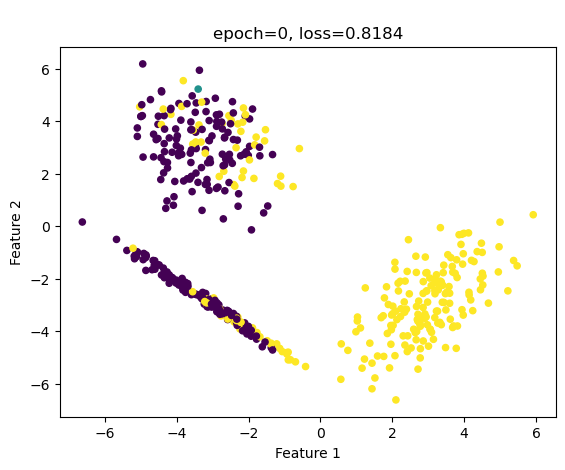

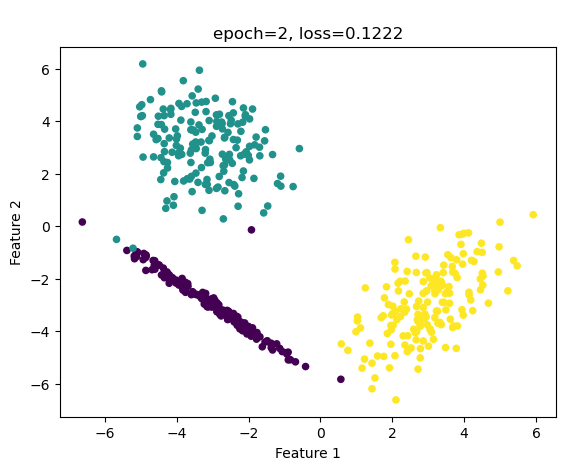

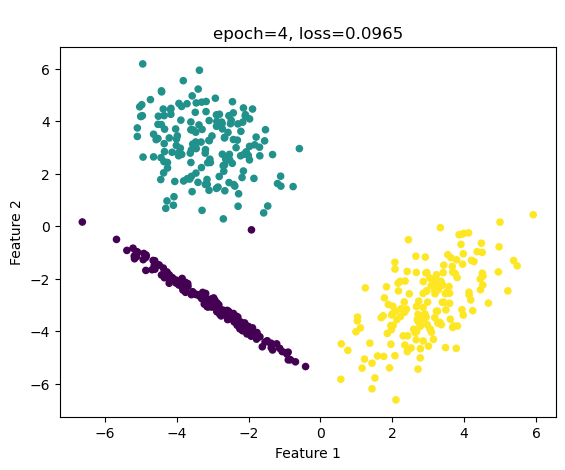

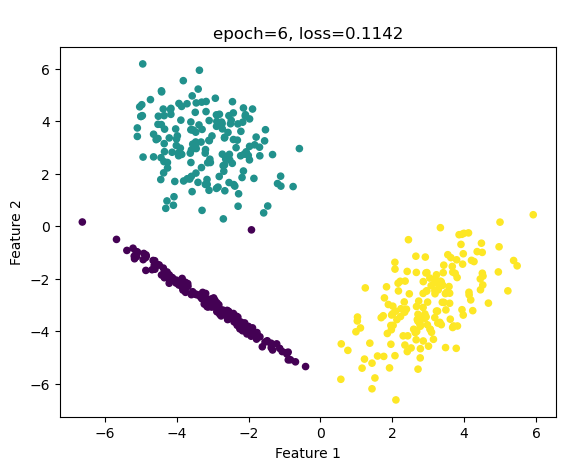

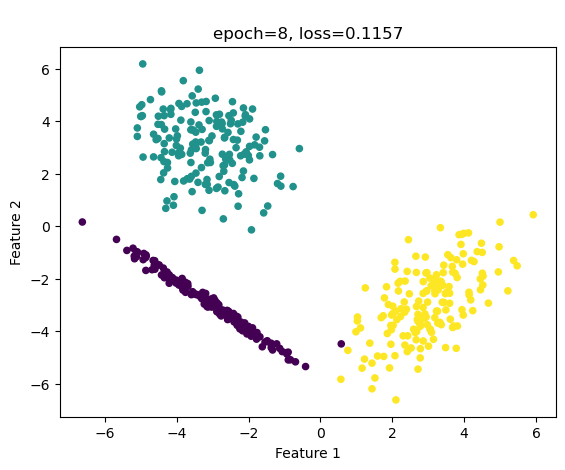

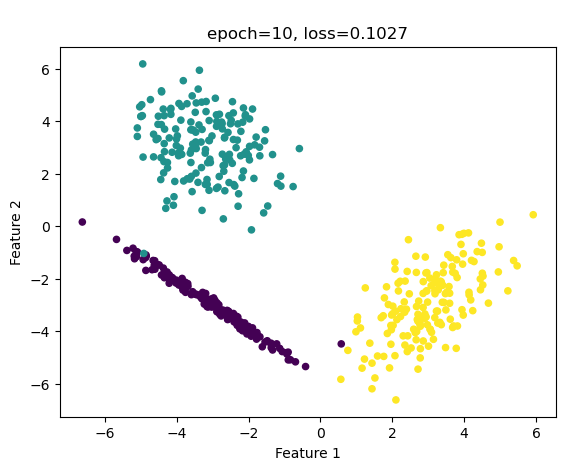

In [277]:
probs = utils.do_multiclass_classification(X=X, labels=labels,loss_function=nn.CrossEntropyLoss())

Which optimization algorighthm you use also matters to the convergence.

**Exercise**: Pass torch's gradient descent (SGD) optimization algorithm to `utils.do_multiclass_classification`. (You can remove `loss_function = nn.CrossEntropyLoss()` as that's set as the default loss function.) Looking at the loss as well as the plots over the course of the training, is the convergence faster or slower than before?

**Hint**: Use the `optimizer` argument of `utils.do_multiclass_classification`.

epoch 0, Loss: 0.8184
epoch 2, Loss: 0.5564
epoch 4, Loss: 0.4067
epoch 6, Loss: 0.3188
epoch 8, Loss: 0.2634
epoch 10, Loss: 0.2257


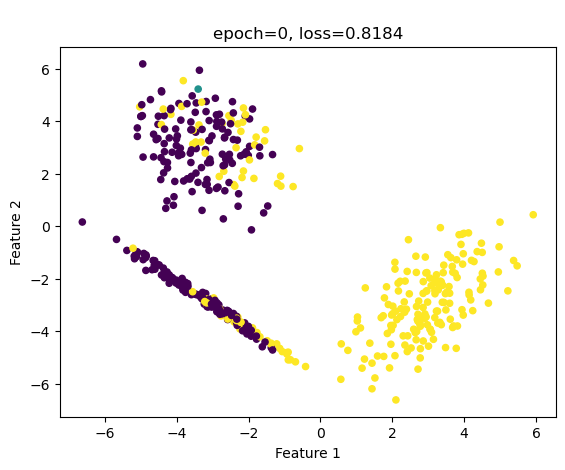

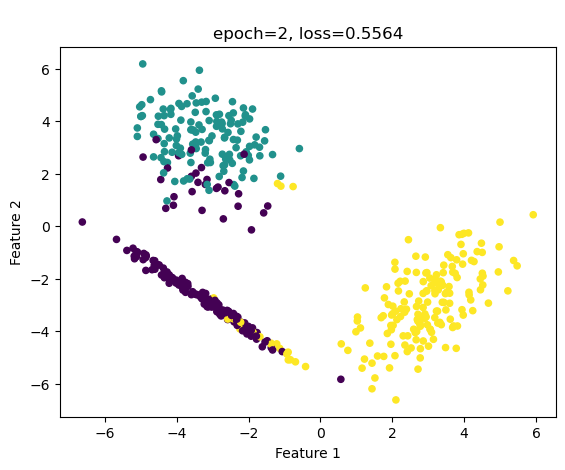

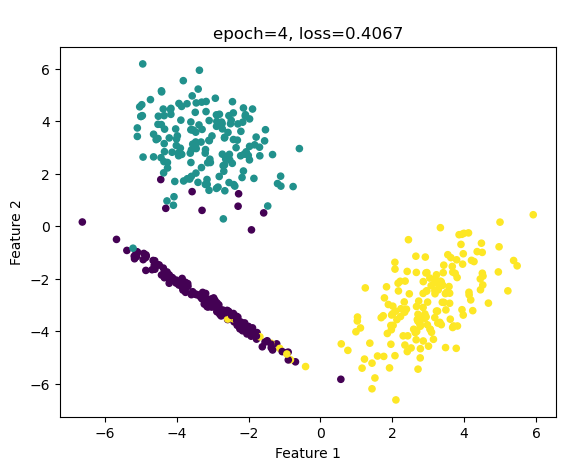

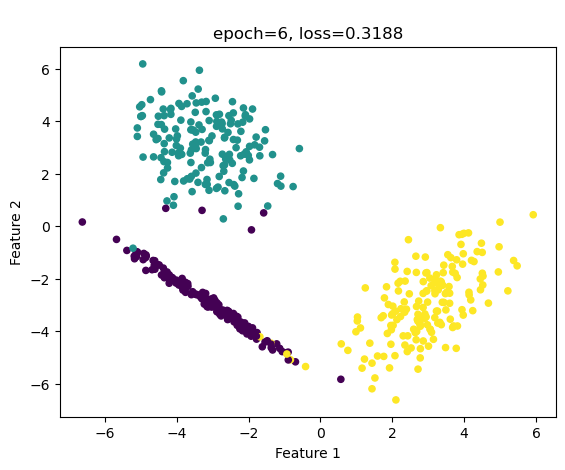

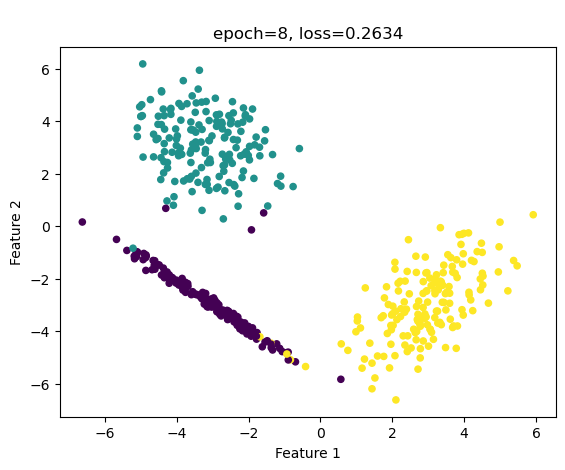

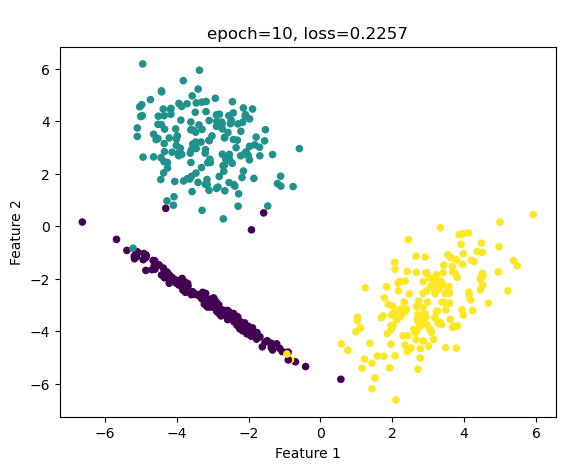

In [278]:
probs = utils.do_multiclass_classification(X=X, labels=labels, optimizer=torch.optim.SGD)

**Exercise**: Pass torch's root mean squared propagation algorithm to `utils.do_multiclass_classification` as the optimizer. RMSprop is an adaptive method - it adapts the learning parameter to each parameter. 
Looking at the loss as well as the plots over the course of the training, is the convergence faster or slower than with gradient Descent?

In [ ]:
probs = utils.do_multiclass_classification(X=X, labels=labels, optimizer=torch.optim.RMSprop)

By default, the `utils.do_multiclass_classification` function uses `Adam` - Adaptive Moment Estimation - which combines RMSprop with momentum. TODO: Explain what momentum is.

## Section 4: Accuracy

The output of the network is a score for each class that reflects the networks belief that a data point corresponds to a given class. This is not the same as a class label. To get the output in the form of a class guess by the network, we have to determine which class the network thinks that a data point is most likely to belong to using the output scores.

| Code | Description |
| --- | --- |
| `torch.argmax(x, dim=1)` | Finds the index at which the **tensor** `x` has the highest value along its dimension 1. |
| `np.argmax(x, axis=1)` | Finds the index at which the **array** `x` has the highest value along axis 1. |
| `a == b` | Compares each element of the tensors (or arrays) `a` and `b` and returns a tensor of boolean (`True` or `False`) values indicating which elements are the same (`True`) and different (`False`). |
| `(a == b).sum()` or `torch.sum(a == b)`| Sums all elements where the condition `a == b` is `True`. `True` is counted as 1, `False` as 0. |
| `(a == b).sum() / len(a)` | Calculates proportion of elements in `a` where the element is equal to the corresponding element in `b`.|

epoch 0, Loss: 0.8184
epoch 2, Loss: 0.1222
epoch 4, Loss: 0.0965
epoch 6, Loss: 0.1142
epoch 8, Loss: 0.1157
epoch 10, Loss: 0.1027


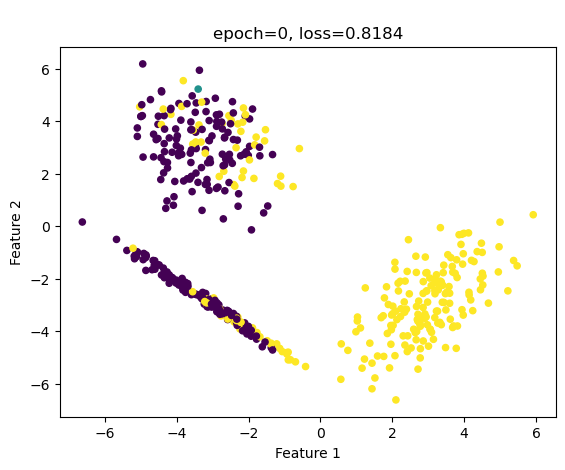

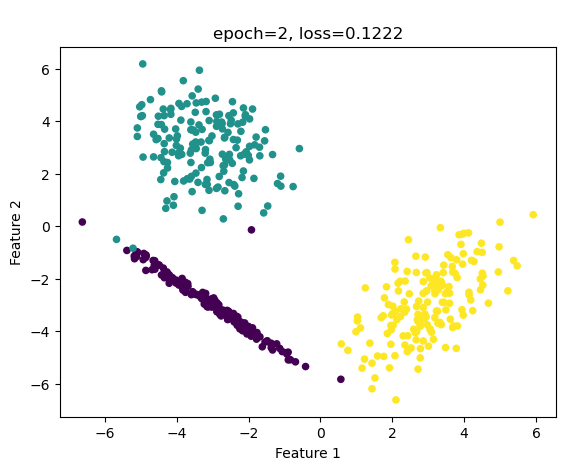

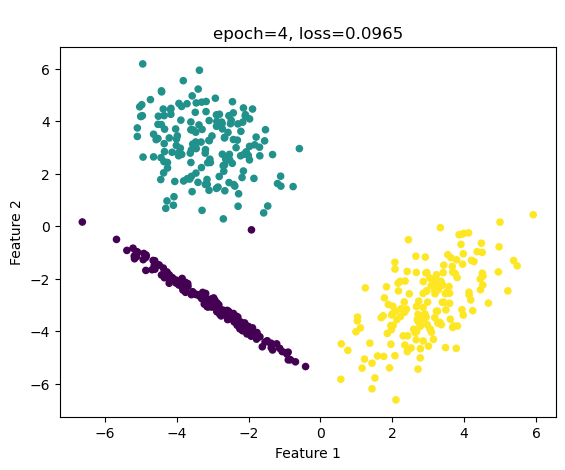

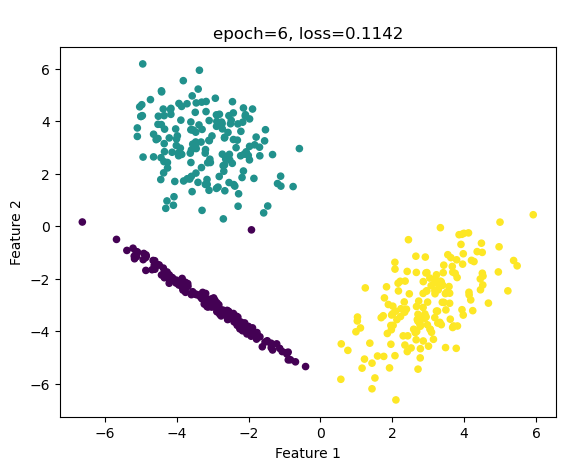

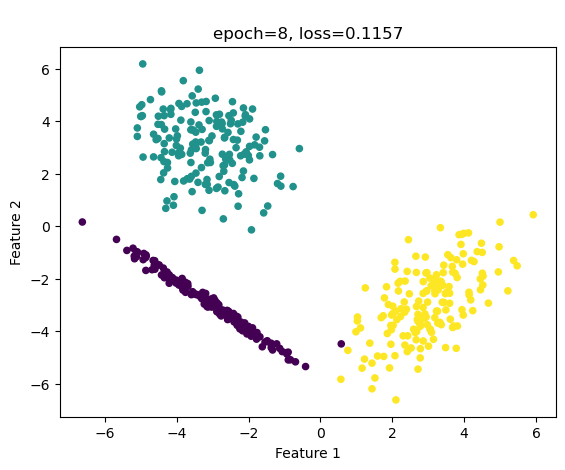

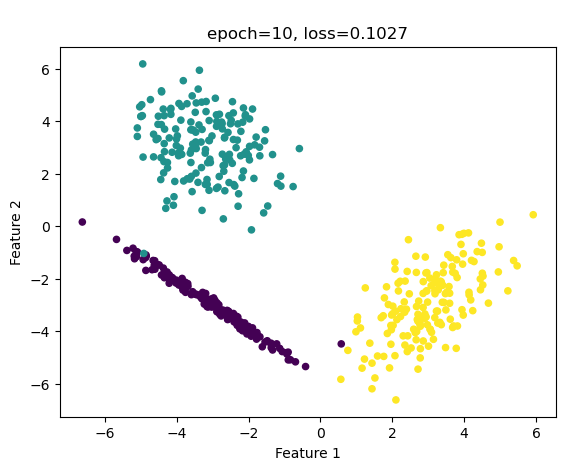

In [280]:
probs = utils.do_multiclass_classification(X=X, labels=labels)

In [287]:
predicted_labels = np.argmax(probs, axis=1)
accuracy = (predicted_labels == labels).sum() / len(labels)
accuracy

tensor(0.9880)